### Prepared by: 
Yuting Chen 259430, 
Kacper Miklaszewski 243215, 
Jakub Szlarzyński 241004

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib_venn import venn3

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif,
    chi2
)

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    Normalizer,
    KBinsDiscretizer,
    LabelEncoder,
    OrdinalEncoder
)

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

df = pd.read_csv("data_clean/S2_cleaned_data.csv")

In [10]:
print("START")
print(df.dtypes)
print(df.describe())

START
Student_ID               int64
Age                      int64
Gender                  object
University_Year         object
Sleep_Duration         float64
Study_Hours            float64
Screen_Time            float64
Caffeine_Intake          int64
Physical_Activity        int64
Sleep_Quality            int64
Weekday_Sleep_Start    float64
Weekend_Sleep_Start    float64
Weekday_Sleep_End      float64
Weekend_Sleep_End      float64
cluster_kmeans           int32
cluster_gmm              int64
cluster_dbscan           int64
outlier_ocsvm            int64
outlier_lof              int64
outlier_iforest          int64
outlier_votes            int64
dtype: object
       Student_ID        Age  Sleep_Duration  Study_Hours  Screen_Time  Caffeine_Intake  Physical_Activity  Sleep_Quality  Weekday_Sleep_Start  Weekend_Sleep_Start  Weekday_Sleep_End  Weekend_Sleep_End  cluster_kmeans  cluster_gmm  cluster_dbscan  outlier_ocsvm  outlier_lof  outlier_iforest  outlier_votes
count  500.000000  500

## 1. Dimension Reduction

======================================== Selected features =====================================
 ['Screen_Time', 'Weekend_Sleep_End', 'Study_Hours', 'Weekday_Sleep_Start', 'Physical_Activity']

Standardized features successfully.

PCA fitted and data transformed successfully.


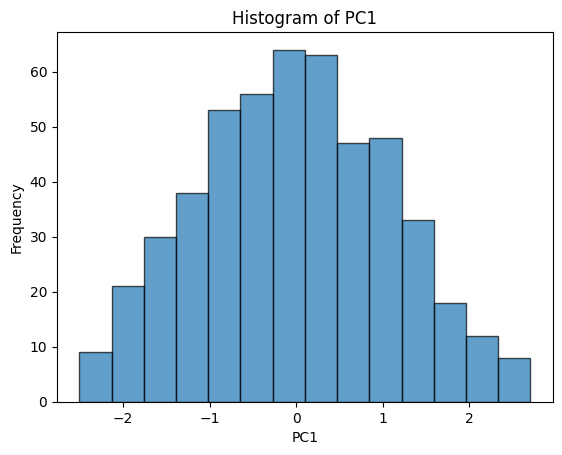


===============Variance Comparison: Original vs PCA Features===============
                                 Type  Variance  Explained_Variance_Ratio
Screen_Time          Original Feature  1.000000                       NaN
Weekend_Sleep_End    Original Feature  1.000000                       NaN
Study_Hours          Original Feature  1.000000                       NaN
Weekday_Sleep_Start  Original Feature  1.000000                       NaN
Physical_Activity    Original Feature  1.000000                       NaN
PC1                     PCA Component  1.206013                   0.24072


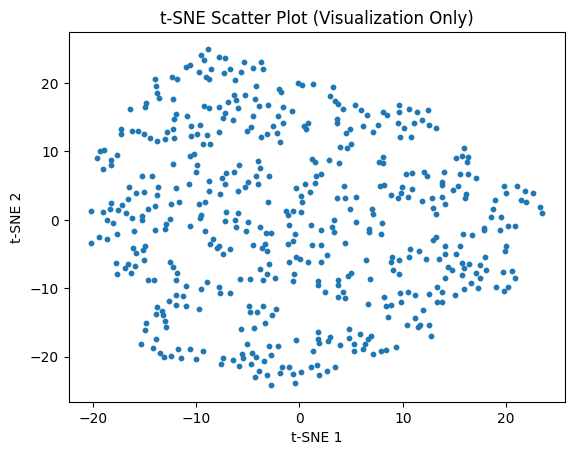

t-SNE scatter plotted successfully.


In [2]:
#1.1PCA
# a,select 5 features with high correlation
numeric_df = df.select_dtypes(include=np.number).drop(columns=["Student_ID"])

corr_matrix = numeric_df.corr().abs() # compute correlation matrix

upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
) # get upper triangle of correlation matrix

avg_corr = upper_tri.mean().sort_values(ascending=False) #compute average correlation 

selected_features = avg_corr.head(5).index.tolist() # select top 5 most correlated features

print("======================================== Selected features =====================================\n", selected_features)

# b,standardize the features
features = [
    "Screen_Time",
    "Weekend_Sleep_End",
    "Study_Hours",
    "Weekday_Sleep_Start",
    "Physical_Activity"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # standardize
print("\nStandardized features successfully.") 

# c, apply PCA
pca = PCA(n_components=3) # choose number of components

X_pca = pca.fit_transform(X_scaled) # fit PCA and transform data

print("\nPCA fitted and data transformed successfully.")

pc1 = X_pca[:, 0] 

# d, plot histogram of PC1
# Histogram of PC1
plt.hist(pc1, bins="auto", alpha=0.7, edgecolor="black")
plt.xlabel("PC1")
plt.ylabel("Frequency")
plt.title("Histogram of PC1")
plt.show()

# e, compare variance
# original features are standardized -> variance = 1
original_variance = np.var(X_scaled, axis=0)

pca_variance = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_

# original features table
original_df = pd.DataFrame({
    "Type": "Original Feature",
    "Variance": original_variance
}, index=features)

# Keep only the first principal component
pca_variance_pc1 = pca_variance[0]
explained_ratio_pc1 = explained_ratio[0]

# PCA features table (PC1 only)
pca_df = pd.DataFrame({
    "Type": ["PCA Component"],
    "Variance": [pca_variance_pc1],
    "Explained_Variance_Ratio": [explained_ratio_pc1]
}, index=["PC1"])

# combine into one comparison table
comparison_df = pd.concat([original_df, pca_df])

print("\n===============Variance Comparison: Original vs PCA Features===============")
print(comparison_df)

#1.2t-SNE
# a, plot scatter
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
# b,visualization only
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=10)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Scatter Plot (Visualization Only)")
plt.show()

print("t-SNE scatter plotted successfully.")

### Dimension Reduction Analysis
PCA was applied to reduce the dimensionality of the dataset. The original features were standardized, so all original features have a variance of 1. PCA generated one new reduced feature, PC1.

Compared with the original features, PC1 has a variance of 1.21, indicating that PCA successfully combines information from multiple features into a single component.

The histogram of PC1 shows a roughly normal distribution, suggesting that the reduced feature is well balanced.

t-SNE was used only for visualization. The scatter plot does not show clear separation in two dimensions, suggesting that the data does not exhibit strong natural groupings.

## 2. Feature Selection

In [3]:
# 2.1 Variance Thresholding
print("\n======== VARIANCE THRESHOLDING ========")

# a. Select numeric columns
X_num = df.select_dtypes(include=["int64", "float64"])
print(f"Total numeric features: {X_num.shape[1]}")

# b. Scale numeric data
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# c. Apply Variance Threshold
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_num_scaled)

# d. Get kept vs removed features
mask_vt = vt.get_support()
kept_features_vt = X_num.columns[mask_vt]
removed_features_vt = X_num.columns[~mask_vt]

# e. Output (STRICT structure)
print("Kept features:", list(kept_features_vt))
print("Removed features:", list(removed_features_vt))


# 2.2 SelectKBest
print("\n======== SELECTKBEST ========")

# a. Define target
y = df["Sleep_Quality"]

# b. Initialize SelectKBest
selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_num_scaled, y)

# c. Get selected vs removed features
mask_kbest = selector.get_support()
selected_features = X_num.columns[mask_kbest]
removed_features = X_num.columns[~mask_kbest]

# d. Output (STRICT structure)
print("Selected features:", list(selected_features))
print("Removed features:", list(removed_features))

# e. Optional but GOOD: score table (teacher-friendly)
scores_df = pd.DataFrame({
    "Feature": X_num.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

print("\nFeature scores:")
print(scores_df)


#2.3 chi-squared test
print("\n=============== Chi-Square ===============")
#a. Encode categorical features
cat_cols = ["Gender", "University_Year"]
X_cat = df[cat_cols].copy()

encoder = LabelEncoder()
for col in cat_cols:
    X_cat[col] = encoder.fit_transform(X_cat[col])

#b. Define target (y)
y = df["Sleep_Quality"]

#c. Apply Chi-Square
chi_scores, p_values = chi2(X_cat, y)

#d. Show scores
chi_result = pd.DataFrame({
    "Feature": cat_cols,
    "Chi2_Score": chi_scores,
    "p_value": p_values
})

print(chi_result)


======== VARIANCE THRESHOLDING ========
Total numeric features: 12
Kept features: ['Student_ID', 'Age', 'Sleep_Duration', 'Study_Hours', 'Screen_Time', 'Caffeine_Intake', 'Physical_Activity', 'Sleep_Quality', 'Weekday_Sleep_Start', 'Weekend_Sleep_Start', 'Weekday_Sleep_End', 'Weekend_Sleep_End']
Removed features: []

======== SELECTKBEST ========
Selected features: ['Study_Hours', 'Caffeine_Intake', 'Sleep_Quality', 'Weekend_Sleep_Start', 'Weekend_Sleep_End']
Removed features: ['Student_ID', 'Age', 'Sleep_Duration', 'Screen_Time', 'Physical_Activity', 'Weekday_Sleep_Start', 'Weekday_Sleep_End']

Feature scores:
                Feature         Score
7         Sleep_Quality  7.981640e+16
9   Weekend_Sleep_Start  1.058063e+00
3           Study_Hours  1.032723e+00
5       Caffeine_Intake  1.012783e+00
11    Weekend_Sleep_End  9.173779e-01
8   Weekday_Sleep_Start  8.561618e-01
1                   Age  8.101373e-01
4           Screen_Time  6.603539e-01
10    Weekday_Sleep_End  5.907401e-01


### Feature Selection Analysis
Three feature selection methods were applied.

Variance Thresholding did not remove any numeric features. This indicates that all numeric variables show sufficient variability and none are constant or near-constant.

SelectKBest identified five numeric features as the most informative: Study_Hours, Caffeine_Intake, Sleep_Quality, Weekend_Sleep_Start, and Weekend_Sleep_End. Other features were removed because they showed weaker statistical relationships with the target.

Chi-Square test was applied to categorical features (Gender and University_Year). Both features have high p-values (> 0.05), indicating no strong statistical association with the target variable.

## 3. Feature Preprocessing

In [4]:
#3.1 Categorical Features Encoding
cat_cols = ["Gender", "University_Year"]

print("======= 3.1 Categorical Encoding =======")
#a, ordinal encoding
print("------ Ordinal Encoding ------")
ordinal_encoder = OrdinalEncoder()
X_ordinal = df[cat_cols].copy()
X_ordinal[cat_cols] = ordinal_encoder.fit_transform(X_ordinal[cat_cols])
print(X_ordinal.head())

#b,label encoding
print("\n------ Label Encoding ------")
X_label = df[cat_cols].copy()
label_encoder = LabelEncoder()
for col in cat_cols:
    X_label[col] = label_encoder.fit_transform(X_label[col])
print(X_label.head())

#c, one-hot encoding
print("\n------------------------- One-Hot Encoding -------------------------")
# Gender
print("[Gender]")
gender_onehot = pd.get_dummies(df["Gender"], prefix="Gender")
print(gender_onehot.head())

# University Year
print("\n[University Year]")
year_onehot = pd.get_dummies(df["University_Year"], prefix="Year")
print(year_onehot.head())


======= 3.1 Categorical Encoding =======
------ Ordinal Encoding ------
   Gender  University_Year
0     2.0              1.0
1     1.0              0.0
2     1.0              3.0
3     2.0              3.0
4     1.0              3.0

------ Label Encoding ------
   Gender  University_Year
0       2                1
1       1                0
2       1                3
3       2                3
4       1                3

------------------------- One-Hot Encoding -------------------------
[Gender]
   Gender_female  Gender_male  Gender_other
0          False        False          True
1          False         True         False
2          False         True         False
3          False        False          True
4          False         True         False

[University Year]
   Year_1st year  Year_2nd year  Year_3rd year  Year_4th year
0          False           True          False          False
1           True          False          False          False
2          False          

### Categorical Features Encoding Analysis
The dataset includes two categorical features: Gender and University_Year. Three encoding methods were compared.

Ordinal encoding assigns ordered numerical values and is suitable for University_Year, which has a natural order. It is not appropriate for Gender, as no inherent ranking exists.

Label encoding converts categories into integers but may introduce misleading order information. Therefore, it is not recommended for distance-based analysis.

One-hot encoding represents categories as binary variables and avoids false ordering. It is the most suitable method for Gender.

Conclusion:
Ordinal encoding is best for University_Year, while one-hot encoding is most appropriate for Gender.

====================================== NORMALIZATION =====================================
Normalization done
   Study_Hours  Caffeine_Intake  Sleep_Quality  Weekend_Sleep_Start  \
0     0.517929         0.131121       0.655606             0.265520   
1     0.404838         0.337365       0.134946             0.479059   
2     0.266268         0.198707       0.198707             0.813508   
3     0.517338         0.240622       0.541400             0.245435   
4     0.232444         0.000000       0.258271             0.526873   

   Weekend_Sleep_End  
0           0.462858  
1           0.688900  
2           0.433977  
3           0.566666  
4           0.775674  


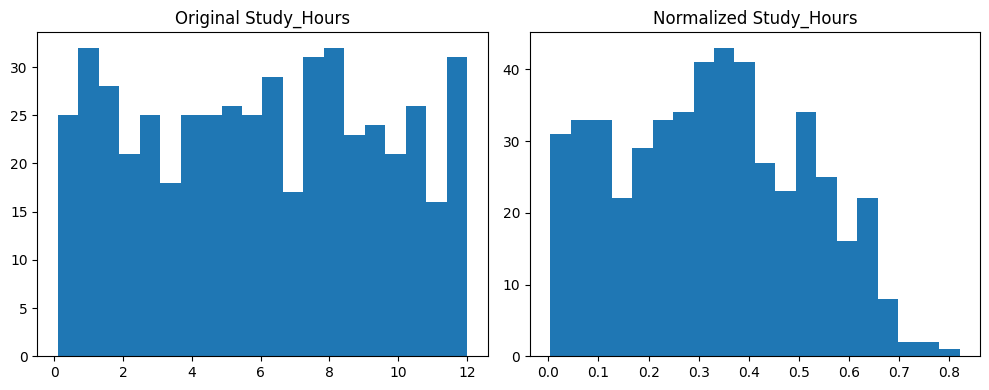

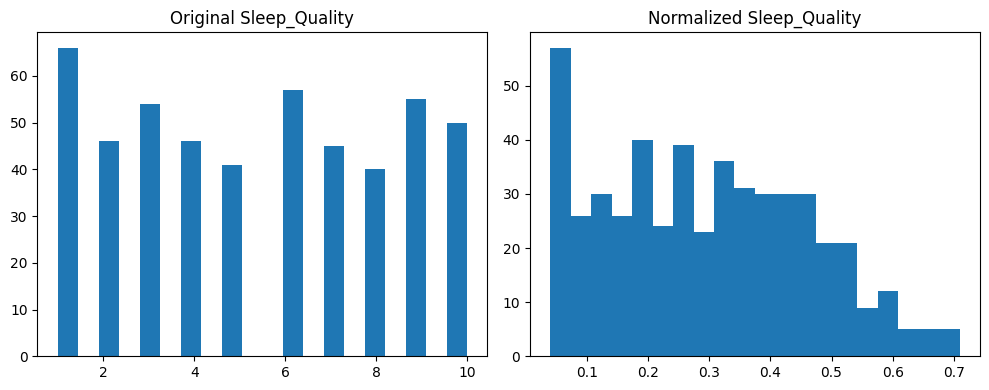

-------- Original statistics --------
      Study_Hours  Sleep_Quality
mean     5.981600       5.362000
min      0.100000       1.000000
max     12.000000      10.000000
var     12.080663       8.804565
std      3.475725       2.967249

------- Normalized statistics -------
      Study_Hours  Sleep_Quality
mean     0.324491       0.295262
min      0.003899       0.040053
max      0.820038       0.709311
var      0.034399       0.027386
std      0.185469       0.165488

======================================== STANDARDIZATION ======================================
Standardization done
   Study_Hours  Caffeine_Intake  Sleep_Quality  Weekend_Sleep_Start  \
0     0.552495        -0.274895       1.564630            -1.439509   
1     0.005299         1.510138      -1.134171            -0.912176   
2     0.206898         1.510138      -0.122121             1.399446   
3     0.754094         0.915127       1.227279            -1.434322   
4    -0.945094        -1.464917      -0.796821        

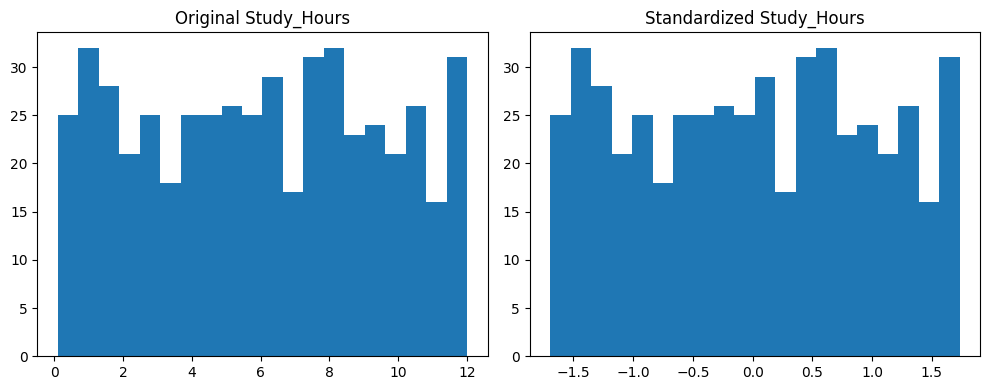

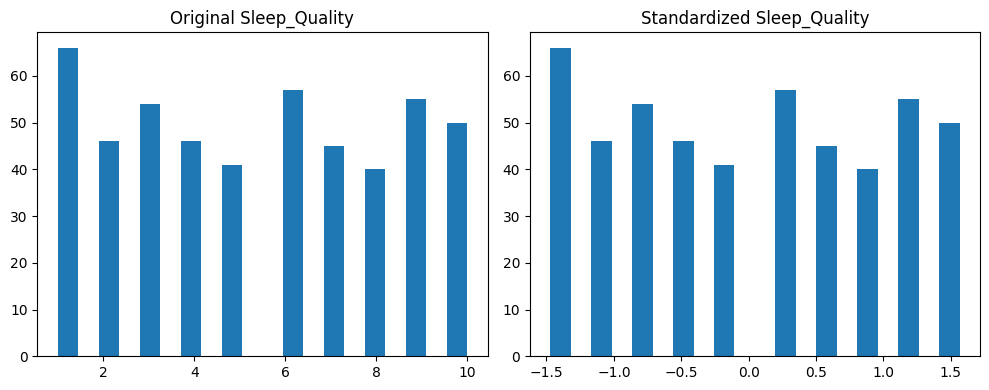

-------- Original statistics --------
      Study_Hours  Sleep_Quality
mean     5.981600       5.362000
min      0.100000       1.000000
max     12.000000      10.000000
var     12.080663       8.804565
std      3.475725       2.967249

------- Standardized statistics -------
      Study_Hours  Sleep_Quality
mean       -0.000         -0.000
min        -1.694         -1.472
max         1.733          1.565
var         1.002          1.002
std         1.001          1.001


In [5]:
#3.2 Numerical Features Encoding
# a, normalization
print("====================================== NORMALIZATION =====================================")

num_features = [
    'Study_Hours',
    'Caffeine_Intake',
    'Sleep_Quality',
    'Weekend_Sleep_Start',
    'Weekend_Sleep_End'
]

X_num = df[num_features]

# apply normalization
normalizer = Normalizer(norm="l2")
X_norm = normalizer.fit_transform(X_num)

norm_df = pd.DataFrame(X_norm, columns=num_features)

print("Normalization done")
print(norm_df.head())

# visualization
features_vis = ['Study_Hours', 'Sleep_Quality']
for feature in features_vis:
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.hist(df[feature], bins=20)
    plt.title(f'Original {feature}')

    plt.subplot(1, 2, 2)
    plt.hist(norm_df[feature], bins=20)
    plt.title(f'Normalized {feature}')

    plt.tight_layout()
    plt.show()
    
# statistics comparison
features_vis = ['Study_Hours', 'Sleep_Quality']

print("-------- Original statistics --------")
print(df[features_vis].agg(['mean', 'min', 'max', 'var', 'std']))

print("\n------- Normalized statistics -------")
print(norm_df[features_vis].agg(['mean', 'min', 'max', 'var', 'std']))

#b, standardization
print("\n======================================== STANDARDIZATION ======================================")
# clustering features
num_features = [
    'Study_Hours',
    'Caffeine_Intake',
    'Sleep_Quality',
    'Weekend_Sleep_Start',
    'Weekend_Sleep_End'
]

X_num = df[num_features]

scaler = StandardScaler()
X_std = scaler.fit_transform(X_num)

std_df = pd.DataFrame(X_std, columns=num_features)

print("Standardization done")
print(std_df.head())

#  visualization
for feature in features_vis:
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.hist(df[feature], bins=20)
    plt.title(f'Original {feature}')

    plt.subplot(1, 2, 2)
    plt.hist(std_df[feature], bins=20)
    plt.title(f'Standardized {feature}')

    plt.tight_layout()
    plt.show()

#statistics comparison
features_vis = ['Study_Hours', 'Sleep_Quality']

print("-------- Original statistics --------")
print(df[features_vis].agg(['mean', 'min', 'max', 'var', 'std']))

print("\n------- Standardized statistics -------")
print(std_df[features_vis].agg(['mean','min','max','var','std']).round(3))

### Normalization Analysis
Comparison and influence:
Normalization rescales values to a smaller range. For Study_Hours and Sleep_Quality, the mean, variance, and standard deviation decrease, showing reduced data spread.

Effect on statistics:
Mean: decreased;
Min / Max: rescaled;
Variance / Standard deviation: reduced.

Purpose:
Normalization reduces the influence of large values and makes features comparable in scale.

### Standardization Analysis
Comparison and influence:
Standardization transforms features to have a mean close to 0 and a standard deviation close to 1. For Study_Hours and Sleep_Quality, the overall shape of the distribution remains the same, but values are centered and scaled.

Effect on statistics:
Mean: becomes approximately 0;
Min / Max: rescaled to negative and positive values;
Variance: approximately 1;
Standard deviation: approximately 1.

Purpose:
Standardization ensures that features are on the same scale, prevents features with larger ranges from dominating the analysis, and is especially important for distance-based methods such as KMeans, GMM, and DBSCAN.

## 4. Clustering

In [6]:
# 4.1 KMeans

# a. Select features for clustering
features = [
    'Study_Hours',
    'Caffeine_Intake',
    'Sleep_Quality',
    'Weekend_Sleep_Start',
    'Weekend_Sleep_End'
]
X = df[features]

# b. Standardize features (required for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# c. Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# d. Output 1: clustering result table (labels)
print("KMEANS CLUSTER LABELS")
print(df[['cluster_kmeans']].head())

# e. Output 2: cluster statistics table
cluster_summary_kmeans = (
    df
    .groupby('cluster_kmeans')[features]
    .mean()
)

cluster_summary_kmeans['count'] = (
    df['cluster_kmeans']
    .value_counts()
    .sort_index()
)

print("\n========================================= KMEANS CLUSTER SUMMARY ==========================================")
print(cluster_summary_kmeans)


# 4.2 Gaussian Mixture Model (GMM)

# a. Select features for clustering
features = [
    'Study_Hours',
    'Caffeine_Intake',
    'Sleep_Quality',
    'Weekend_Sleep_Start',
    'Weekend_Sleep_End'
]
X = df[features]

# b. Standardize features (required for GMM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# c. Apply Gaussian Mixture
gmm = GaussianMixture(n_components=3, random_state=42)
df['cluster_gmm'] = gmm.fit_predict(X_scaled)

# d. Output 1: clustering result table (labels)
print("\nGMM CLUSTER LABELS")
print(df[['cluster_gmm']].head())

# e. Output 2: cluster statistics table
cluster_summary_gmm = (
    df
    .groupby('cluster_gmm')[features]
    .mean()
)

cluster_summary_gmm['count'] = (
    df['cluster_gmm']
    .value_counts()
    .sort_index()
)

print("\n================================ GMM CLUSTER SUMMARY =================================")
print(cluster_summary_gmm)


# 4.3 DBSCAN
# a. Select features for clustering
features = [
    'Study_Hours',
    'Caffeine_Intake',
    'Sleep_Quality',
    'Weekend_Sleep_Start',
    'Weekend_Sleep_End'
]
X = df[features]

# b. Standardize features (required for DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# c. Apply DBSCAN
dbscan = DBSCAN(eps=1, min_samples=5)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

# d. Output 1: clustering result table (labels)
print("\nDBSCAN CLUSTER LABELS")
print(df[['cluster_dbscan']].head())

# e. Output 2: cluster statistics table (exclude outliers -1)
cluster_summary_dbscan = (
    df[df['cluster_dbscan'] != -1]
    .groupby('cluster_dbscan')[features]
    .mean()
)

cluster_summary_dbscan['count'] = (
    df[df['cluster_dbscan'] != -1]['cluster_dbscan']
    .value_counts()
    .sort_index()
)

print("\n================================= DBSCAN CLUSTER SUMMARY (EXCLUDING OUTLIERS) =================================")
print(cluster_summary_dbscan)

# f. Optional but useful: outlier count (text only)
print("\nOutliers (label = -1):", (df['cluster_dbscan'] == -1).sum())

KMEANS CLUSTER LABELS
   cluster_kmeans
0               1
1               2
2               1
3               1
4               0

========================================= KMEANS CLUSTER SUMMARY ==========================================
                Study_Hours  Caffeine_Intake  Sleep_Quality  \
cluster_kmeans                                                
0                  2.584971         2.202312       4.034682   
1                  6.723596         2.410112       8.224719   
2                  9.038926         2.825503       3.483221   

                Weekend_Sleep_Start  Weekend_Sleep_End  count  
cluster_kmeans                                                 
0                         11.332370           8.741561    173  
1                         14.502865           9.254157    178  
2                         11.046443           8.956510    149  

GMM CLUSTER LABELS
   cluster_gmm
0            1
1            2
2            2
3            1
4            0

==============

### Clustering Analysis
1,Created clusters analysis (per method)
KMeans created three well-balanced clusters that mainly differ in Study_Hours and Sleep_Quality. One cluster shows low study time with poorer sleep quality, one shows moderate study time with the best sleep quality, and one represents high study time with reduced sleep quality.

Gaussian Mixture Model (GMM) also produced three clusters with patterns very similar to KMeans. However, GMM assigns samples probabilistically, allowing smoother transitions between clusters, especially for students with medium study intensity.

DBSCAN identified eight clusters and detected about 24% of samples as outliers. One large dense cluster represents typical behavior, while several small clusters and outliers capture extreme or uncommon sleep–study patterns.

2,Comparison of methods
KMeans and GMM produced stable and interpretable results, making them suitable for identifying overall behavioral patterns. DBSCAN behaved differently due to its density-based nature and was more sensitive to parameter selection, but it was effective in highlighting noise and rare cases.

3,Common pattern checking
All three methods show a consistent pattern: students with higher study hours tend to have lower sleep quality, while students with moderate study hours generally report better sleep quality. Extreme study or sleep behaviors are often grouped into small clusters or identified as outliers.

4,Conclusion
Overall, KMeans and GMM are better suited for summarizing the main structure of the dataset, while DBSCAN complements them by identifying outliers and atypical behaviors.

## 5. Outlier Detection

One-Class SVM -> normal: 447 outliers: 53
=================================== One-Class SVM outliers (first 5) ===================================
    Study_Hours  Caffeine_Intake  Sleep_Quality  Weekend_Sleep_Start  Weekend_Sleep_End  outlier_ocsvm
0           7.9                2             10                 4.05               7.06             -1
22         10.4                2             10                20.47              10.80             -1
25          8.7                4              1                 3.26              10.88             -1
32         10.9                1              1                 5.10              10.32             -1
37          1.6                0              1                21.12              10.07             -1

LOF -> normal: 450 outliers: 50
===================================== LOF outliers (first 5) ========================================
    Study_Hours  Caffeine_Intake  Sleep_Quality  Weekend_Sleep_Start  Weekend_Sleep_End  outlier_lof

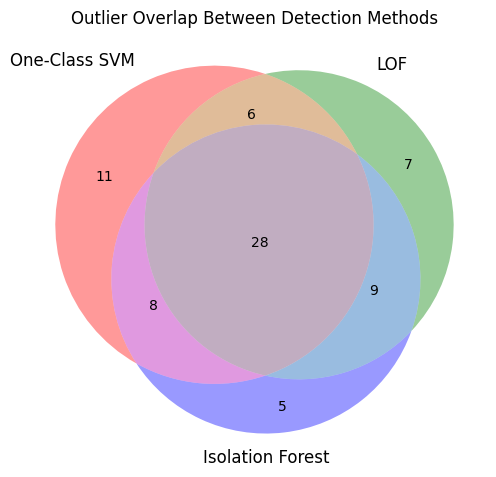

In [7]:
#5.1 oneclassSVM
# a, Select the same features used in clustering
features = [
    'Study_Hours',
    'Caffeine_Intake',
    'Sleep_Quality',
    'Weekend_Sleep_Start',
    'Weekend_Sleep_End'
]
X = df[features]

# b, Standardize (IMPORTANT for One-Class SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# c, Fit One-Class SVM
# nu ≈ expected outlier fraction (start with 0.1 = 10%)
# gamma='scale' is a safe default
ocsvm = OneClassSVM(kernel='rbf', nu=0.10, gamma='scale')
df['outlier_ocsvm'] = ocsvm.fit_predict(X_scaled)

# d, Summary
n_outliers = int(np.sum(df['outlier_ocsvm'] == -1))
n_normals = int(np.sum(df['outlier_ocsvm'] == 1))
print("One-Class SVM -> normal:", n_normals, "outliers:", n_outliers)

# e, View a few outliers
outliers_ocsvm = df.loc[
    df['outlier_ocsvm'] == -1,
    features + ['outlier_ocsvm']
]

pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

print("=================================== One-Class SVM outliers (first 5) ===================================")
print(outliers_ocsvm.head())

#5.2 Local Outlier Factor (LOF)
# b, Standardize (IMPORTANT for LOF)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# c, Apply Local Outlier Factor
# n_neighbors: size of local neighborhood
# contamination: expected proportion of outliers
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.10)
df['outlier_lof'] = lof.fit_predict(X_scaled)

# d, Summary
n_outliers = int(np.sum(df['outlier_lof'] == -1))
n_normals = int(np.sum(df['outlier_lof'] == 1))
print("\nLOF -> normal:", n_normals, "outliers:", n_outliers)

# e, View a few outliers
print("===================================== LOF outliers (first 5) ========================================")
print(df.loc[df['outlier_lof'] == -1, features + ['outlier_lof']].head())

#5.3 Isolation Forest
# b, Standardize (recommended for fair comparison across methods)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# c, Apply Isolation Forest
# contamination: expected proportion of outliers
iso = IsolationForest(
    n_estimators=300,
    contamination=0.10,
    random_state=42
)
df['outlier_iforest'] = iso.fit_predict(X_scaled)

# d, Summary
n_outliers = int(np.sum(df['outlier_iforest'] == -1))
n_normals = int(np.sum(df['outlier_iforest'] == 1))
print("\nIsolation Forest -> normal:", n_normals, "outliers:", n_outliers)

# e, View a few outliers
df.loc[df['outlier_iforest'] == -1, features + ['outlier_iforest']].head()

print("================================ Isolation Forest outliers (first 5) ===================================")
print(df.loc[df['outlier_iforest'] == -1, features + ['outlier_iforest']].head())

#Outlier output analysis
methods = ["outlier_ocsvm", "outlier_lof", "outlier_iforest"]
n = len(df)

# a. Counts + overlap comparison
print("=== Outlier counts per method ===")
for m in methods:
    cnt = (df[m] == -1).sum()
    print(f"{m}: {cnt} ({cnt/n*100:.1f}%)")

# overlap: how many methods flag each sample
df["outlier_votes"] = (df[methods] == -1).sum(axis=1)

print("\n====== Outlier overlap ======")
print("Flagged by ≥1 method:", (df["outlier_votes"] >= 1).sum())
print("Flagged by ≥2 methods:", (df["outlier_votes"] >= 2).sum())
print("Flagged by all 3 methods:", (df["outlier_votes"] == 3).sum())

# b. Inspect the same outliers
# samples flagged by at least 2 methods
common_outliers = df.loc[
    df["outlier_votes"] >= 2,
    features + methods
]

print("\n======================================================= Common outliers (first 5) ====================================================")
print(common_outliers.head())

# c. visualization common patterns_Venn Diagram
# sets of outlier indices for each method
set_ocsvm = set(df.index[df["outlier_ocsvm"] == -1])
set_lof = set(df.index[df["outlier_lof"] == -1])
set_iforest = set(df.index[df["outlier_iforest"] == -1])

plt.figure(figsize=(6, 6))
venn3(
    [set_ocsvm, set_lof, set_iforest],
    set_labels=("One-Class SVM", "LOF", "Isolation Forest")
)

plt.title("Outlier Overlap Between Detection Methods")
plt.show()

### Outlier Detection Analysis

Method results:
One-Class SVM detected 53 outliers (10.6%), while LOF and Isolation Forest each detected 50 outliers (10.0%). One-Class SVM is slightly more sensitive, identifying a few additional extreme cases.

Method comparison:
LOF and Isolation Forest show very similar behavior in both the number and type of detected outliers, whereas One-Class SVM is more boundary-oriented and flags slightly more observations as anomalies.

Common pattern analysis:
A total of 28 samples were detected as outliers by all three methods, and 51 samples by at least two methods. These common outliers are mainly characterized by extreme Study_Hours, very low or very high Sleep_Quality, and unusual weekend sleep start or end times, indicating irregular sleep–study behavior.

Conclusion:
Despite differences in sensitivity, all three methods consistently identify a core group of abnormal sleep patterns, suggesting the detected outliers represent genuine atypical student behaviors rather than method-specific noise.

In [11]:
print("END")
print(df.dtypes)
print(df.describe())

END
Student_ID               int64
Age                      int64
Gender                  object
University_Year         object
Sleep_Duration         float64
Study_Hours            float64
Screen_Time            float64
Caffeine_Intake          int64
Physical_Activity        int64
Sleep_Quality            int64
Weekday_Sleep_Start    float64
Weekend_Sleep_Start    float64
Weekday_Sleep_End      float64
Weekend_Sleep_End      float64
cluster_kmeans           int32
cluster_gmm              int64
cluster_dbscan           int64
outlier_ocsvm            int64
outlier_lof              int64
outlier_iforest          int64
outlier_votes            int64
dtype: object
       Student_ID        Age  Sleep_Duration  Study_Hours  Screen_Time  Caffeine_Intake  Physical_Activity  Sleep_Quality  Weekday_Sleep_Start  Weekend_Sleep_Start  Weekday_Sleep_End  Weekend_Sleep_End  cluster_kmeans  cluster_gmm  cluster_dbscan  outlier_ocsvm  outlier_lof  outlier_iforest  outlier_votes
count  500.000000  500.0